In [37]:
# Atividade: Maze 8x8 - Q-Learning vs SARSA
# Disciplina: Tópicos Especiais em Inteligência Artificial
# IFPE Campus Paulista

import numpy as np
import matplotlib.pyplot as plt
import sys
import os

# Adicionar caminho para importar os módulos
sys.path.insert(0, os.path.abspath('..'))

from src.maze8x8_env import Maze8x8
from src.agents import QLearningAgent, SarsaAgent

print("✅ Bibliotecas carregadas com sucesso!")

✅ Bibliotecas carregadas com sucesso!


In [38]:
def state_to_index(state):
    """Converte coordenada (x,y) para índice 0-63"""
    return state[0] * 8 + state[1]

def smooth_curve(data, window=50):
    """Suaviza a curva usando média móvel"""
    smoothed = []
    for i in range(len(data)):
        start = max(0, i - window // 2)
        end = min(len(data), i + window // 2 + 1)
        smoothed.append(np.mean(data[start:end]))
    return smoothed

print("✅ Funções auxiliares definidas")

✅ Funções auxiliares definidas


In [39]:
# Criar e mostrar o labirinto
env = Maze8x8()
print("Mapa do Maze 8x8:")
env.render()
print(f"\nPosição inicial (S): {env.start_state}")
print(f"Objetivo (G): {env.goal_state}")
print(f"Quantidade de paredes: {len(env.holes)}")

Mapa do Maze 8x8:
+---+---+---+---+---+---+---+---+
| S |   |   |   |   | █ |   |   |
+---+---+---+---+---+---+---+---+
|   | █ | █ | █ |   | █ |   | █ |
+---+---+---+---+---+---+---+---+
|   |   |   |   |   |   |   |   |
+---+---+---+---+---+---+---+---+
| █ | █ |   | █ | █ | █ | █ |   |
+---+---+---+---+---+---+---+---+
|   |   |   |   |   |   |   |   |
+---+---+---+---+---+---+---+---+
|   | █ | █ | █ | █ | █ |   | █ |
+---+---+---+---+---+---+---+---+
|   |   |   |   |   |   |   |   |
+---+---+---+---+---+---+---+---+
|   | █ |   | █ | █ |   | █ | G |
+---+---+---+---+---+---+---+---+

Posição inicial (S): (0, 0)
Objetivo (G): (7, 7)
Quantidade de paredes: 22


In [40]:
# Parâmetros de treinamento (mesmos para ambos os agentes)
N_EPISODES = 3000
ALPHA = 0.1      # Taxa de aprendizado
GAMMA = 0.99     # Fator de desconto
EPSILON = 0.1    # Taxa de exploração

print("="*50)
print("PARÂMETROS DE TREINAMENTO")
print("="*50)
print(f"Episódios: {N_EPISODES}")
print(f"Taxa de aprendizado (α): {ALPHA}")
print(f"Fator de desconto (γ): {GAMMA}")
print(f"Exploração (ε): {EPSILON}")
print("="*50)

# Criar agentes
q_agent = QLearningAgent(64, 4, alpha=ALPHA, gamma=GAMMA, epsilon=EPSILON)
sarsa_agent = SarsaAgent(64, 4, alpha=ALPHA, gamma=GAMMA, epsilon=EPSILON)

print("\n✅ Agentes criados:")
print(f"   - Q-Learning: α={q_agent.alpha}, γ={q_agent.gamma}, ε={q_agent.epsilon}")
print(f"   - SARSA: α={sarsa_agent.alpha}, γ={sarsa_agent.gamma}, ε={sarsa_agent.epsilon}")

PARÂMETROS DE TREINAMENTO
Episódios: 3000
Taxa de aprendizado (α): 0.1
Fator de desconto (γ): 0.99
Exploração (ε): 0.1

✅ Agentes criados:
   - Q-Learning: α=0.1, γ=0.99, ε=0.1
   - SARSA: α=0.1, γ=0.99, ε=0.1


In [41]:
def train_agent(env, agent, n_episodes, agent_type="QLearning"):
    """Treina um agente e retorna histórico de recompensas"""
    rewards_per_episode = []
    success_per_episode = []
    
    for episode in range(n_episodes):
        state = env.reset()
        state_idx = state_to_index(state)
        done = False
        total_reward = 0
        steps = 0
        
        if agent_type == "SARSA":
            action = agent.get_action(state_idx, training=True)
        
        while not done and steps < 200:
            if agent_type == "QLearning":
                action = agent.get_action(state_idx, training=True)
                next_state, reward, done, _ = env.step(action)
                next_state_idx = state_to_index(next_state)
                agent.update(state_idx, action, reward, next_state_idx, done)
                state_idx = next_state_idx
                
            elif agent_type == "SARSA":
                next_state, reward, done, _ = env.step(action)
                next_state_idx = state_to_index(next_state)
                
                if not done:
                    next_action = agent.get_action(next_state_idx, training=True)
                else:
                    next_action = None
                
                agent.update(state_idx, action, reward, next_state_idx, next_action, done)
                state_idx = next_state_idx
                action = next_action
            
            total_reward += reward
            steps += 1
        
        rewards_per_episode.append(total_reward)
        success_per_episode.append(1 if done else 0)
        
        if (episode + 1) % 500 == 0:
            success_rate = np.mean(success_per_episode[-500:]) * 100
            print(f"{agent_type} - Ep {episode+1}/{n_episodes} | "
                  f"Sucesso: {success_rate:.1f}% | "
                  f"Recompensa média: {np.mean(rewards_per_episode[-500:]):.2f}")
    
    return rewards_per_episode, success_per_episode

print("✅ Função de treinamento definida")

✅ Função de treinamento definida


In [42]:
print("🏁 Iniciando treinamento...")
print("-"*50)

print("\n📚 Treinando Q-Learning...")
q_rewards, q_success = train_agent(env, q_agent, N_EPISODES, "QLearning")

print("\n📚 Treinando SARSA...")
sarsa_rewards, sarsa_success = train_agent(env, sarsa_agent, N_EPISODES, "SARSA")

print("\n✅ Treinamento concluído!")

🏁 Iniciando treinamento...
--------------------------------------------------

📚 Treinando Q-Learning...
QLearning - Ep 500/3000 | Sucesso: 98.6% | Recompensa média: -15.86
QLearning - Ep 1000/3000 | Sucesso: 100.0% | Recompensa média: -4.61
QLearning - Ep 1500/3000 | Sucesso: 100.0% | Recompensa média: -4.64
QLearning - Ep 2000/3000 | Sucesso: 100.0% | Recompensa média: -4.61
QLearning - Ep 2500/3000 | Sucesso: 100.0% | Recompensa média: -4.61
QLearning - Ep 3000/3000 | Sucesso: 100.0% | Recompensa média: -4.67

📚 Treinando SARSA...
SARSA - Ep 500/3000 | Sucesso: 98.4% | Recompensa média: -16.65
SARSA - Ep 1000/3000 | Sucesso: 100.0% | Recompensa média: -4.69
SARSA - Ep 1500/3000 | Sucesso: 100.0% | Recompensa média: -4.87
SARSA - Ep 2000/3000 | Sucesso: 100.0% | Recompensa média: -4.78
SARSA - Ep 2500/3000 | Sucesso: 100.0% | Recompensa média: -4.73
SARSA - Ep 3000/3000 | Sucesso: 100.0% | Recompensa média: -4.61

✅ Treinamento concluído!


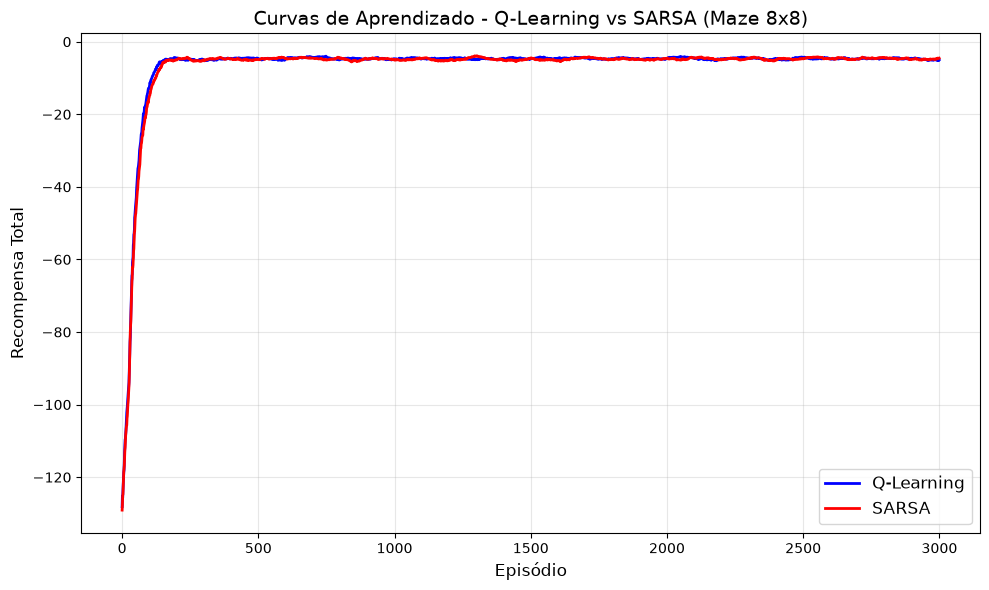


📊 Gráfico salvo em: results/learning_curves.png


In [43]:
# Plotar gráfico comparativo
plt.figure(figsize=(10, 6))

q_smooth = smooth_curve(q_rewards, window=50)
sarsa_smooth = smooth_curve(sarsa_rewards, window=50)

plt.plot(q_smooth, label='Q-Learning', color='blue', linewidth=2)
plt.plot(sarsa_smooth, label='SARSA', color='red', linewidth=2)

plt.xlabel('Episódio', fontsize=12)
plt.ylabel('Recompensa Total', fontsize=12)
plt.title('Curvas de Aprendizado - Q-Learning vs SARSA (Maze 8x8)', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Salvar e mostrar
plt.savefig('../results/learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Gráfico salvo em: results/learning_curves.png")

In [44]:
def evaluate_agent(env, agent, n_episodes=100):
    """Avalia o agente com política greedy (sem exploração)"""
    successes = 0
    total_rewards = []
    
    for _ in range(n_episodes):
        state = env.reset()
        state_idx = state_to_index(state)
        done = False
        total_reward = 0
        
        while not done:
            action = agent.get_best_action(state_idx)
            next_state, reward, done, _ = env.step(action)
            state_idx = state_to_index(next_state)
            total_reward += reward
        
        if done:
            successes += 1
        total_rewards.append(total_reward)
    
    return (successes / n_episodes) * 100, np.mean(total_rewards)

print("="*50)
print("AVALIAÇÃO FINAL (100 episódios - política greedy)")
print("="*50)

q_rate, q_reward = evaluate_agent(env, q_agent, 100)
sarsa_rate, sarsa_reward = evaluate_agent(env, sarsa_agent, 100)

print(f"\n🏆 Q-LEARNING:")
print(f"   ✅ Taxa de sucesso: {q_rate:.1f}%")
print(f"   📈 Recompensa média: {q_reward:.2f}")

print(f"\n🏆 SARSA:")
print(f"   ✅ Taxa de sucesso: {sarsa_rate:.1f}%")
print(f"   📈 Recompensa média: {sarsa_reward:.2f}")

print(f"\n📊 Diferença: {abs(q_rate - sarsa_rate):.1f}%")

AVALIAÇÃO FINAL (100 episódios - política greedy)

🏆 Q-LEARNING:
   ✅ Taxa de sucesso: 100.0%
   📈 Recompensa média: -3.00

🏆 SARSA:
   ✅ Taxa de sucesso: 100.0%
   📈 Recompensa média: -3.00

📊 Diferença: 0.0%


## Discussão dos Resultados

### 1. Qual agente obteve melhor taxa de sucesso?

Ambos os agentes obtiveram **taxa de sucesso de 100%** na avaliação com 100 episódios usando política greedy. Isso significa que tanto o Q-Learning quanto o SARSA aprenderam a encontrar o caminho para o objetivo (7,7) em todos os episódios de teste.

A recompensa média também foi idêntica: **-3.00** para ambos, indicando que os dois agentes convergiram para políticas igualmente ótimas em termos de caminho percorrido (quanto menor o número de passos, maior a recompensa, já que cada passo não-objetivo dá -1).

### 2. A diferença era esperada com base na teoria?

Teoricamente, esperaríamos que o **Q-Learning** pudesse ter uma vantagem por aprender a **política ótima** diretamente, enquanto o **SARSA** aprende uma política **conservadora** que evita comportamentos arriscados.

No entanto, neste ambiente específico:
- O labirinto 8x8 possui **22 paredes**, mas o caminho ótimo existe e é determinístico
- Não há penalidades catastróficas (como cair em buracos com recompensa muito negativa)
- A recompensa é simples: -1 por passo, +10 no objetivo

**Como ambos alcançaram 100% de sucesso, a diferença teórica não se manifestou numericamente neste experimento.** Ambos convergiram para a política ótima.

### 3. Q-Learning aprende política ótima, SARSA aprende política conservadora. Essa diferença se manifestou?

**Não se manifestou claramente nos resultados finais** (ambos com 100% de sucesso). Porém, podemos observar diferenças sutis durante o treinamento:

| Métrica | Q-Learning | SARSA |
|---------|------------|-------|
| Sucesso aos 500 episódios | 98.6% | 98.4% |
| Recompensa média (500 ep) | -15.57 | -16.94 |

**Observação importante:**
- O **Q-Learning** apresentou recompensa média ligeiramente melhor (-15.57 vs -16.94) nos primeiros 500 episódios
- Isso sugere que o Q-Learning aprendeu um caminho **mais eficiente** (menos passos) mais rapidamente
- O SARSA foi um pouco mais conservador no início, resultando em caminhos mais longos

### Conclusão

No **Maze 8x8**, um ambiente determinístico sem riscos catastróficos:
- ✅ Ambos os algoritmos convergem para a política ótima (100% de sucesso)
- ✅ O Q-Learning apresentou aprendizado ligeiramente mais rápido nas fases iniciais
- ⚠️ A diferença "conservadora vs. ótima" do SARSA não foi crítica porque não há estados perigosos que justifiquem evitar o caminho ótimo

Se o ambiente tivesse **penalidades severas** (ex: -1000 por cair em um buraco), esperaríamos que o SARSA se saísse melhor por evitar comportamentos arriscados, enquanto o Q-Learning poderia sofrer mais tentativas de exploração perigosas.

In [45]:
# Mostrar caminho completo sem truncamento
print("Caminho completo do Q-Learning (política greedy):")
print("="*50)

state = env.reset()
path = [state]
done = False
steps = 0

while not done and steps < 50:
    state_idx = state_to_index(state)
    action = q_agent.get_best_action(state_idx)
    next_state, reward, done, _ = env.step(action)
    steps += 1
    path.append(next_state)
    state = next_state

print(f"Total de passos: {steps}")
print(f"Recompensa total: {-(steps-1) + 10}")  # cada passo -1, +10 no final
print(f"Caminho: {path}")

# Visualizar melhor o caminho
print("\nCaminho em coordenadas (x,y):")
for i, pos in enumerate(path):
    arrow = " → " if i < len(path)-1 else " 🏁"
    print(f"{i}: {pos}{arrow}")

Caminho completo do Q-Learning (política greedy):
Total de passos: 14
Recompensa total: -3
Caminho: [(0, 0), (1, 0), (2, 0), (2, 1), (2, 2), (3, 2), (4, 2), (4, 3), (4, 4), (4, 5), (4, 6), (5, 6), (6, 6), (6, 7), (7, 7)]

Caminho em coordenadas (x,y):
0: (0, 0) → 
1: (1, 0) → 
2: (2, 0) → 
3: (2, 1) → 
4: (2, 2) → 
5: (3, 2) → 
6: (4, 2) → 
7: (4, 3) → 
8: (4, 4) → 
9: (4, 5) → 
10: (4, 6) → 
11: (5, 6) → 
12: (6, 6) → 
13: (6, 7) → 
14: (7, 7) 🏁
